# Instalação das Bibliotecas e Configurações Iniciais

In [1]:
# ===================================================================='
# CÉLULA 1: INSTALAÇÃO E IMPORTAÇÕES
# ===================================================================='
!pip install yfinance pandas scikit-learn matplotlib xgboost ta joblib --user --quiet

import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
import ta
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import xgboost as xgb

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Configuração dos Ativos

In [2]:
# ===================================================================='
# CÉLULA 2: CONFIGURAÇÃO DOS ATIVOS
# ===================================================================='
CONFIG_ATIVOS = {
    "VALE3.SA": {
        "setor": "Mineração",
        "fatores": ['^BVSP', 'CL=F', 'BRL=X', 'GC=F', 'SPY', 'IEF'],
        "nomes_fatores": ['Ibovespa', 'Petroleo', 'Cambio', 'Ouro', 'SP500', 'IEF_10Y']
    },
    "ITUB4.SA": {
        "setor": "Bancário",
        "fatores": ['^BVSP', 'BRL=X', 'IEF', '^VIX', 'SPY'],
        "nomes_fatores": ['Ibovespa', 'Cambio', 'IEF_10Y', 'VIX', 'SP500']
    },
    "LREN3.SA": {
        "setor": "Varejo",
        "fatores": ['^BVSP', 'BRL=X', 'SPY'],
        "nomes_fatores": ['Ibovespa', 'Cambio', 'SP500']
    }
}

# Funções de Coleta e Preparação dos Dados

In [3]:
# CÉLULA 3: FUNÇÕES DE DADOS
def coletar_dados(ticker, fatores, nomes_fatores, start, end):
    print(f"--- Coletando dados para {ticker} ---")
    todos_tickers = list(set([ticker] + fatores))
    dados = yf.download(todos_tickers, start=start, end=end, progress=False, auto_adjust=False)
    if dados.empty: return pd.DataFrame()
    df = pd.DataFrame(index=dados.index)
    df['Abertura'] = dados['Open'][ticker]
    df['Maxima'] = dados['High'][ticker]
    df['Minima'] = dados['Low'][ticker]
    df['Preco_Fechamento'] = dados['Close'][ticker]
    df['Volume'] = dados['Volume'][ticker]
    for fator, nome in zip(fatores, nomes_fatores):
        if fator in dados['Close'].columns: df[nome] = dados['Close'][fator]
        else: print(f"Aviso: Não foi possível baixar o fator '{nome}' ({fator}).")
    return df

def engenharia_fatores(df):
    print("--- Realizando engenharia de fatores ---")
    df['Retorno_1d'] = df['Preco_Fechamento'].pct_change()
    df['Retorno_Futuro'] = df['Preco_Fechamento'].pct_change().shift(-1)
    df['Momentum_5d'] = df['Preco_Fechamento'].pct_change(5)
    df['Volatilidade_10d'] = df['Retorno_1d'].rolling(window=10).std()
    df['RSI_14d'] = ta.momentum.RSIIndicator(close=df['Preco_Fechamento'], window=14).rsi()
    df['SMA_10_50_Ratio'] = ta.trend.SMAIndicator(df['Preco_Fechamento'], window=10).sma_indicator() / ta.trend.SMAIndicator(df['Preco_Fechamento'], window=50).sma_indicator()
    df.dropna(inplace=True)
    if df.empty:
        print("ERRO CRÍTICO: DataFrame ficou vazio.")
        return df
    df['Target_Compra'] = (df['Retorno_Futuro'] > 0.002).astype(int)
    return df

# Funções de Machine Learning 

In [4]:
# CÉLULA 4: FUNÇÕES DE MACHINE LEARNING
def otimizar_modelo(df, features, target):
    print("--- Otimizando modelo com GridSearchCV e TimeSeriesSplit ---")
    X = df[features]
    y = df[target]
    if X.empty: return None, None
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    tscv = TimeSeriesSplit(n_splits=3)
    param_grid_xgb = {"max_depth": [3, 5], "n_estimators": [100, 200], "learning_rate": [0.05, 0.1]}
    xgb_model = xgb.XGBClassifier(objective='binary:logistic', use_label_encoder=False, verbosity=0, eval_metric='logloss', random_state=123)
    gsearch_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=tscv, scoring='accuracy', n_jobs=-1)
    gsearch_xgb.fit(X_scaled, y)
    print(f"Melhores parâmetros encontrados: {gsearch_xgb.best_params_}")
    return gsearch_xgb.best_estimator_, scaler

def fazer_predicoes(modelo, scaler, df, features):
    X = df[features]
    X_scaled = scaler.transform(X)
    proba = modelo.predict_proba(X_scaled)[:, 1]
    return (proba > 0.55).astype(int), proba

# Funções de Simulação (Backtesting) e Gráficos

In [5]:
# CÉLULA 5: FUNÇÕES DE BACKTESTING E VISUALIZAÇÃO
def backtest_com_stops(df, sinais, capital_inicial=10000, stop_loss_pct=0.02, take_profit_pct=0.04):
    print("--- Executando backtest com Stop-Loss e Take-Profit ---")
    capital = capital_inicial
    posicao = 0
    capitais = []
    preco_compra = 0
    for i in range(len(df)):
        preco_atual = df['Preco_Fechamento'].iloc[i]
        if posicao == 1:
            retorno = (preco_atual - preco_compra) / preco_compra
            if retorno <= -stop_loss_pct or retorno >= take_profit_pct:
                capital *= (1 + retorno)
                posicao = 0
                preco_compra = 0
        if sinais[i] == 1 and posicao == 0:
            posicao = 1
            preco_compra = preco_atual
        capitais.append(capital)
    return capitais

def plotar_capital(df, capital_acumulado, ticker):
    df_plot = pd.DataFrame(index=df.index)
    df_plot['Capital'] = capital_acumulado
    df_plot['Benchmark'] = (df['Preco_Fechamento'] / df['Preco_Fechamento'].iloc[0]) * 10000
    plt.figure(figsize=(12, 7))
    plt.plot(df_plot.index, df_plot['Capital'], label='Capital da Estratégia', color='blue')
    plt.plot(df_plot.index, df_plot['Benchmark'], label='Benchmark (Buy & Hold)', color='gray', linestyle='--')
    plt.title(f'Desempenho da Estratégia para {ticker}', fontsize=16)
    plt.xlabel('Data')
    plt.ylabel('Capital (R$)')
    plt.legend()
    plt.grid(True)
    nome_arquivo_grafico = f'desempenho_{ticker}_evento_2024.png'
    plt.savefig(nome_arquivo_grafico)
    print(f"Gráfico de desempenho salvo como: {nome_arquivo_grafico}")
    plt.show()

# Main


================== INICIANDO ANÁLISE DE EVENTO PARA: VALE3.SA ==================
--- Coletando dados para VALE3.SA ---
--- Realizando engenharia de fatores ---
--- Divisão dos Dados ---
Período de Treino: 2019-09-17 a 2023-09-06
Período de Teste: 2024-08-08 a 2024-10-29
--- Otimizando modelo com GridSearchCV e TimeSeriesSplit ---
Melhores parâmetros encontrados: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
--- Executando backtest com Stop-Loss e Take-Profit ---
Gráfico de desempenho salvo como: desempenho_VALE3.SA_evento_2024.png


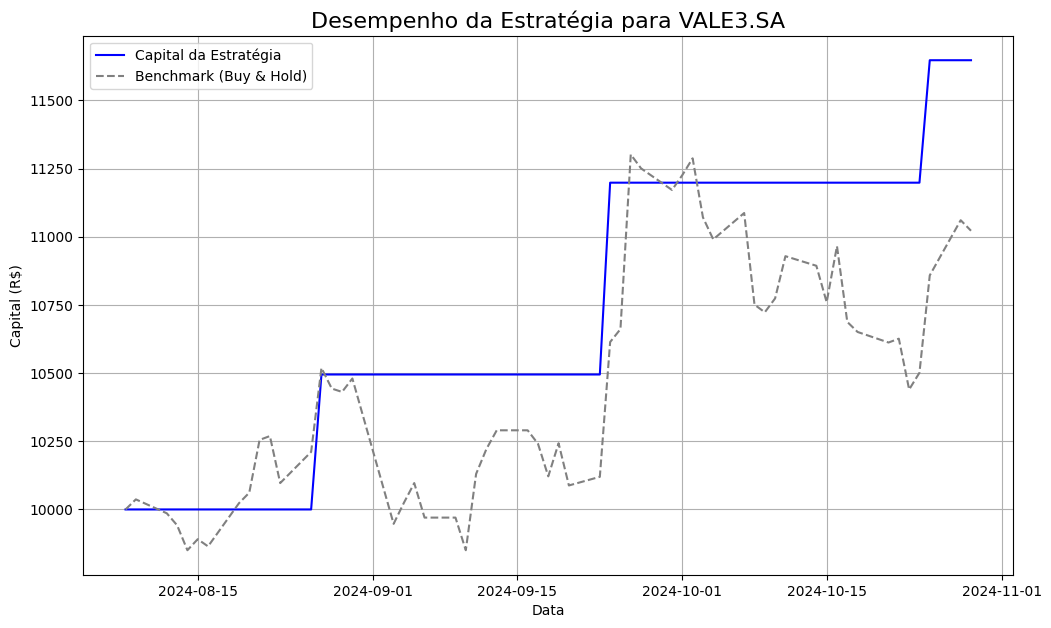


--- Relatório Final do Evento para VALE3.SA ---
Período de Teste (Crise): 01/05/2024 a 31/10/2024
Retorno da Estratégia: 16.47%
Retorno do Benchmark (Buy & Hold): 10.22%
Capital Final Estimado: R$ 11647.35
----------------------------------------

================== INICIANDO ANÁLISE DE EVENTO PARA: ITUB4.SA ==================
--- Coletando dados para ITUB4.SA ---
--- Realizando engenharia de fatores ---
--- Divisão dos Dados ---
Período de Treino: 2019-09-17 a 2023-09-06
Período de Teste: 2024-08-08 a 2024-10-29
--- Otimizando modelo com GridSearchCV e TimeSeriesSplit ---
Melhores parâmetros encontrados: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
--- Executando backtest com Stop-Loss e Take-Profit ---
Gráfico de desempenho salvo como: desempenho_ITUB4.SA_evento_2024.png


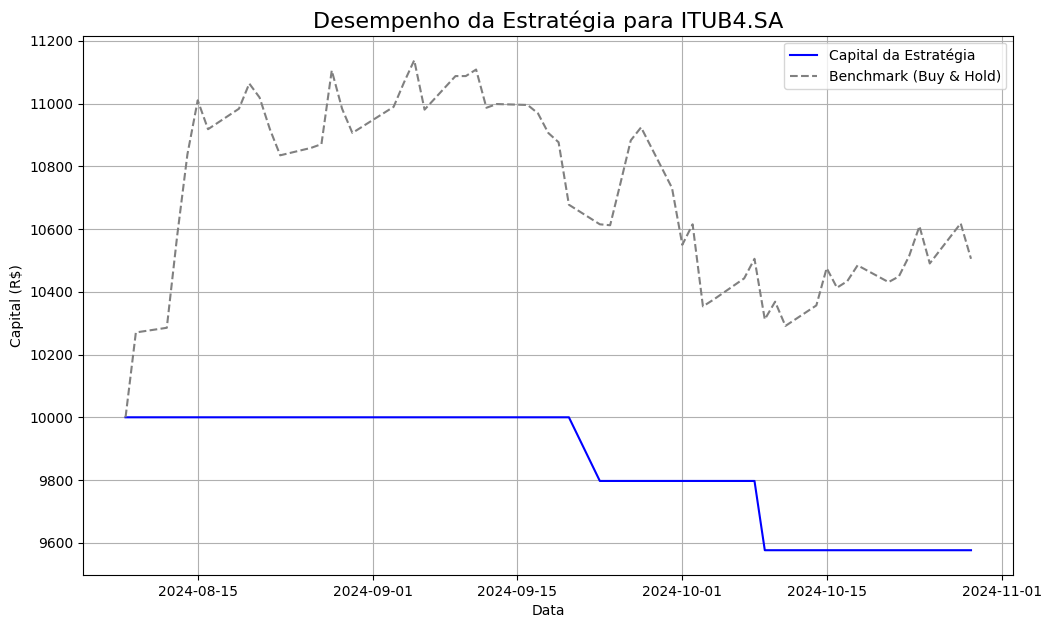


--- Relatório Final do Evento para ITUB4.SA ---
Período de Teste (Crise): 01/05/2024 a 31/10/2024
Retorno da Estratégia: -4.24%
Retorno do Benchmark (Buy & Hold): 5.05%
Capital Final Estimado: R$ 9576.26
----------------------------------------

================== INICIANDO ANÁLISE DE EVENTO PARA: LREN3.SA ==================
--- Coletando dados para LREN3.SA ---
--- Realizando engenharia de fatores ---
--- Divisão dos Dados ---
Período de Treino: 2019-09-17 a 2023-09-06
Período de Teste: 2024-08-08 a 2024-10-29
--- Otimizando modelo com GridSearchCV e TimeSeriesSplit ---
Melhores parâmetros encontrados: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
--- Executando backtest com Stop-Loss e Take-Profit ---
Gráfico de desempenho salvo como: desempenho_LREN3.SA_evento_2024.png


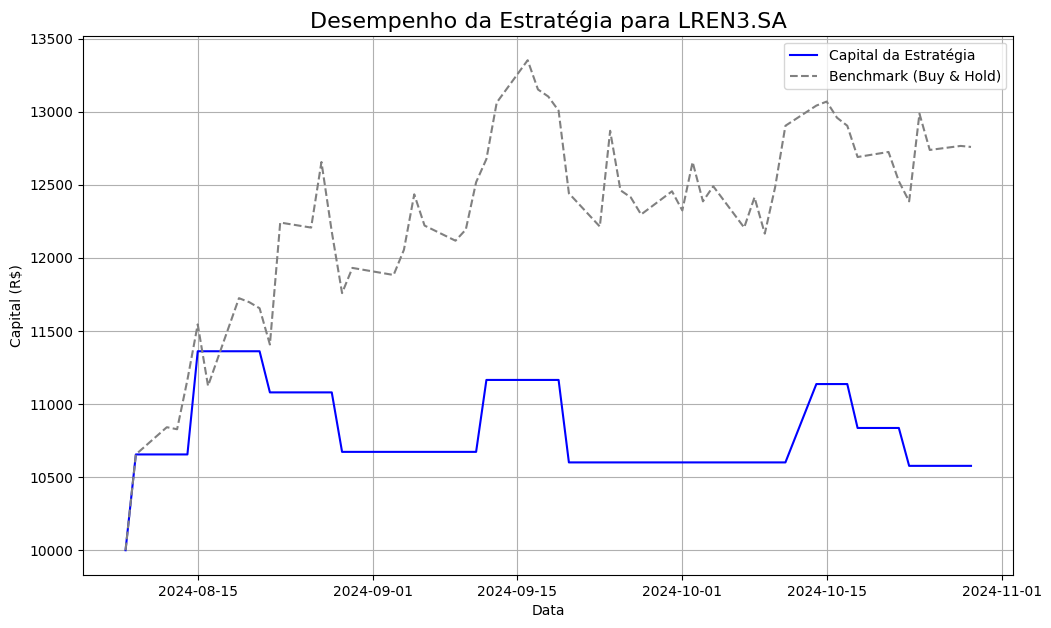


--- Relatório Final do Evento para LREN3.SA ---
Período de Teste (Crise): 01/05/2024 a 31/10/2024
Retorno da Estratégia: 5.77%
Retorno do Benchmark (Buy & Hold): 27.59%
Capital Final Estimado: R$ 10577.12
----------------------------------------


In [6]:
# ===================================================================='
# CÉLULA 6: BLOCO DE EXECUÇÃO - ESTUDO DE EVENTO (ENCHENTES 2024)
# ===================================================================='
if __name__ == "__main__":
    
    # --- Painel de Controle do Backtest de Evento ---
    # Data final para os dados de TREINO. O modelo só "conhecerá" o mundo até esta data.
    DATA_FIM_TREINO = datetime(2024, 4, 30)
    
    # Data de início do TESTE, simulando o período da crise.
    DATA_INICIO_TESTE = datetime(2024, 5, 1)
    
    # Data final do nosso período de análise de teste.
    DATA_FIM_TESTE = datetime(2024, 10, 31)
    
    # A coleta de dados começa 5 anos ANTES do fim do treino.
    start_date_coleta = DATA_FIM_TREINO - timedelta(days=5*365)
    
    # ---------------------------------------------------

    for ativo, conf in CONFIG_ATIVOS.items():
        print("\n" + "="*80)
        print(f" INICIANDO ANÁLISE DE EVENTO PARA: {ativo} ".center(80, "="))
        print("="*80)
        
        # 1. Coleta e Engenharia de Fatores (no período completo)
        df_completo = coletar_dados(ativo, conf['fatores'], conf['nomes_fatores'], start_date_coleta, DATA_FIM_TESTE)
        if df_completo.empty: continue
        
        df_eng_completo = engenharia_fatores(df_completo)
        if df_eng_completo.empty: continue
            
        # 2. Divisão RIGOROSA entre Treino e Teste
        df_treino = df_eng_completo[df_eng_completo.index.date < DATA_FIM_TREINO.date()]
        df_teste = df_eng_completo[df_eng_completo.index.date >= DATA_INICIO_TESTE.date()]
        
        print(f"--- Divisão dos Dados ---")
        print(f"Período de Treino: {df_treino.index.min().strftime('%Y-%m-%d')} a {df_treino.index.max().strftime('%Y-%m-%d')}")
        print(f"Período de Teste: {df_teste.index.min().strftime('%Y-%m-%d')} a {df_teste.index.max().strftime('%Y-%m-%d')}")

        if df_treino.empty or df_teste.empty:
            print("Erro: Conjunto de treino ou teste ficou vazio. Verifique as datas.")
            continue
            
        # 3. Otimização do Modelo (APENAS com dados de treino)
        features = [col for col in df_treino.columns if col not in ['Retorno_Futuro', 'Target_Compra', 'Abertura', 'Maxima', 'Minima', 'Preco_Fechamento', 'Volume']]
        modelo, scaler = otimizar_modelo(df_treino, features, 'Target_Compra')
        if modelo is None: continue

        # 4. Predição (APENAS nos dados de teste, que o modelo nunca viu)
        sinais, proba = fazer_predicoes(modelo, scaler, df_teste, features)
        
        # 5. Backtest (APENAS no período da crise)
        capital_acumulado = backtest_com_stops(df_teste, sinais)
        
        # 6. Visualização e Relatório
        plotar_capital(df_teste, capital_acumulado, ativo)

        retorno_final = (capital_acumulado[-1] / capital_acumulado[0] - 1) * 100
        retorno_benchmark = (df_teste['Preco_Fechamento'].iloc[-1] / df_teste['Preco_Fechamento'].iloc[0] - 1) * 100

        print(f"\n--- Relatório Final do Evento para {ativo} ---")
        print(f"Período de Teste (Crise): {DATA_INICIO_TESTE.strftime('%d/%m/%Y')} a {DATA_FIM_TESTE.strftime('%d/%m/%Y')}")
        print(f"Retorno da Estratégia: {retorno_final:.2f}%")
        print(f"Retorno do Benchmark (Buy & Hold): {retorno_benchmark:.2f}%")
        print(f"Capital Final Estimado: R$ {capital_acumulado[-1]:.2f}")
        print("-" * 40)